# HR Attrition Analysis & Prediction
**Dataset:** IBM HR Analytics — 1,470 employees, 34 features  
**Stack:** Python · SQLite · Scikit-learn · Matplotlib

In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
import os
for fname in uploaded.keys():
    os.rename(fname, 'hr_raw.csv')

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

## 1. Load & Explore

In [4]:
df = pd.read_csv('hr_raw.csv')
print(df.shape)
df.head()

(1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [6]:
print(df['Attrition'].value_counts())
print(f"Attrition rate: {df['Attrition'].value_counts(normalize=True)['Yes']*100:.1f}%")

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition rate: 16.1%


## 2. Data Cleaning & Feature Engineering

In [7]:
df.drop_duplicates(inplace=True)

constant_cols = [col for col in df.columns if df[col].nunique() == 1]
df.drop(columns=constant_cols, inplace=True)
print(f'Dropped constant columns: {constant_cols}')

Dropped constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [8]:
df['Attrition_Binary'] = (df['Attrition'] == 'Yes').astype(int)
df['OverTime_Binary']  = (df['OverTime'] == 'Yes').astype(int)
df['IncomePerYear']    = df['MonthlyIncome'] * 12

df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[0, 2, 5, 10, 20, 100],
    labels=['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs']
)
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 25, 35, 45, 55, 65],
    labels=['18-25', '26-35', '36-45', '46-55', '56+']
)
df['SalaryBand'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, 20000],
    labels=['Low (<3K)', 'Mid (3-6K)', 'High (6-10K)', 'Top (10K+']
)

print(f'Final shape: {df.shape}')
df.head(3)

Final shape: (1470, 38)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Binary,OverTime_Binary,IncomePerYear,TenureGroup,AgeGroup,SalaryBand
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,6,4,0,5,1,1,71916,6-10 yrs,36-45,Mid (3-6K)
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,10,7,1,7,0,0,61560,6-10 yrs,46-55,Mid (3-6K)
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,0,0,0,0,1,1,25080,NaN,36-45,Low (<3K)


In [9]:
df.to_csv('hr_attrition_cleaned.csv', index=False)
print('Saved hr_attrition_cleaned.csv')

Saved hr_attrition_cleaned.csv


## 3. Exploratory Data Analysis

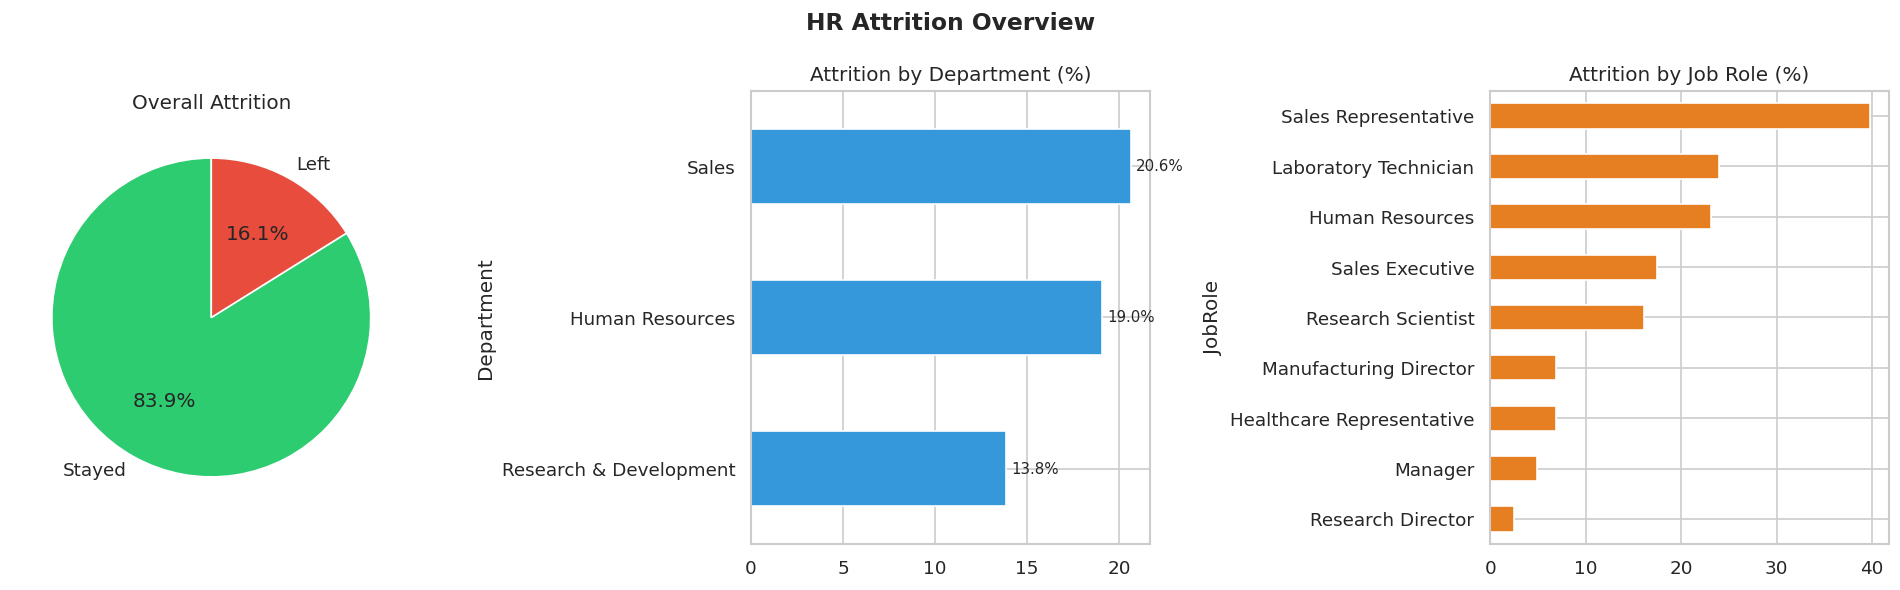

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('HR Attrition Overview', fontsize=14, fontweight='bold')

sizes = df['Attrition'].value_counts()
axes[0].pie(sizes, labels=['Stayed', 'Left'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Overall Attrition')

dept = df.groupby('Department')['Attrition_Binary'].mean() * 100
dept.sort_values().plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Attrition by Department (%)')
for bar, val in zip(axes[1].patches, dept.sort_values()):
    axes[1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)

role = df.groupby('JobRole')['Attrition_Binary'].mean() * 100
role.sort_values().plot(kind='barh', ax=axes[2], color='#e67e22')
axes[2].set_title('Attrition by Job Role (%)')

plt.tight_layout()
plt.savefig('chart1_overview.png', bbox_inches='tight')
plt.show()

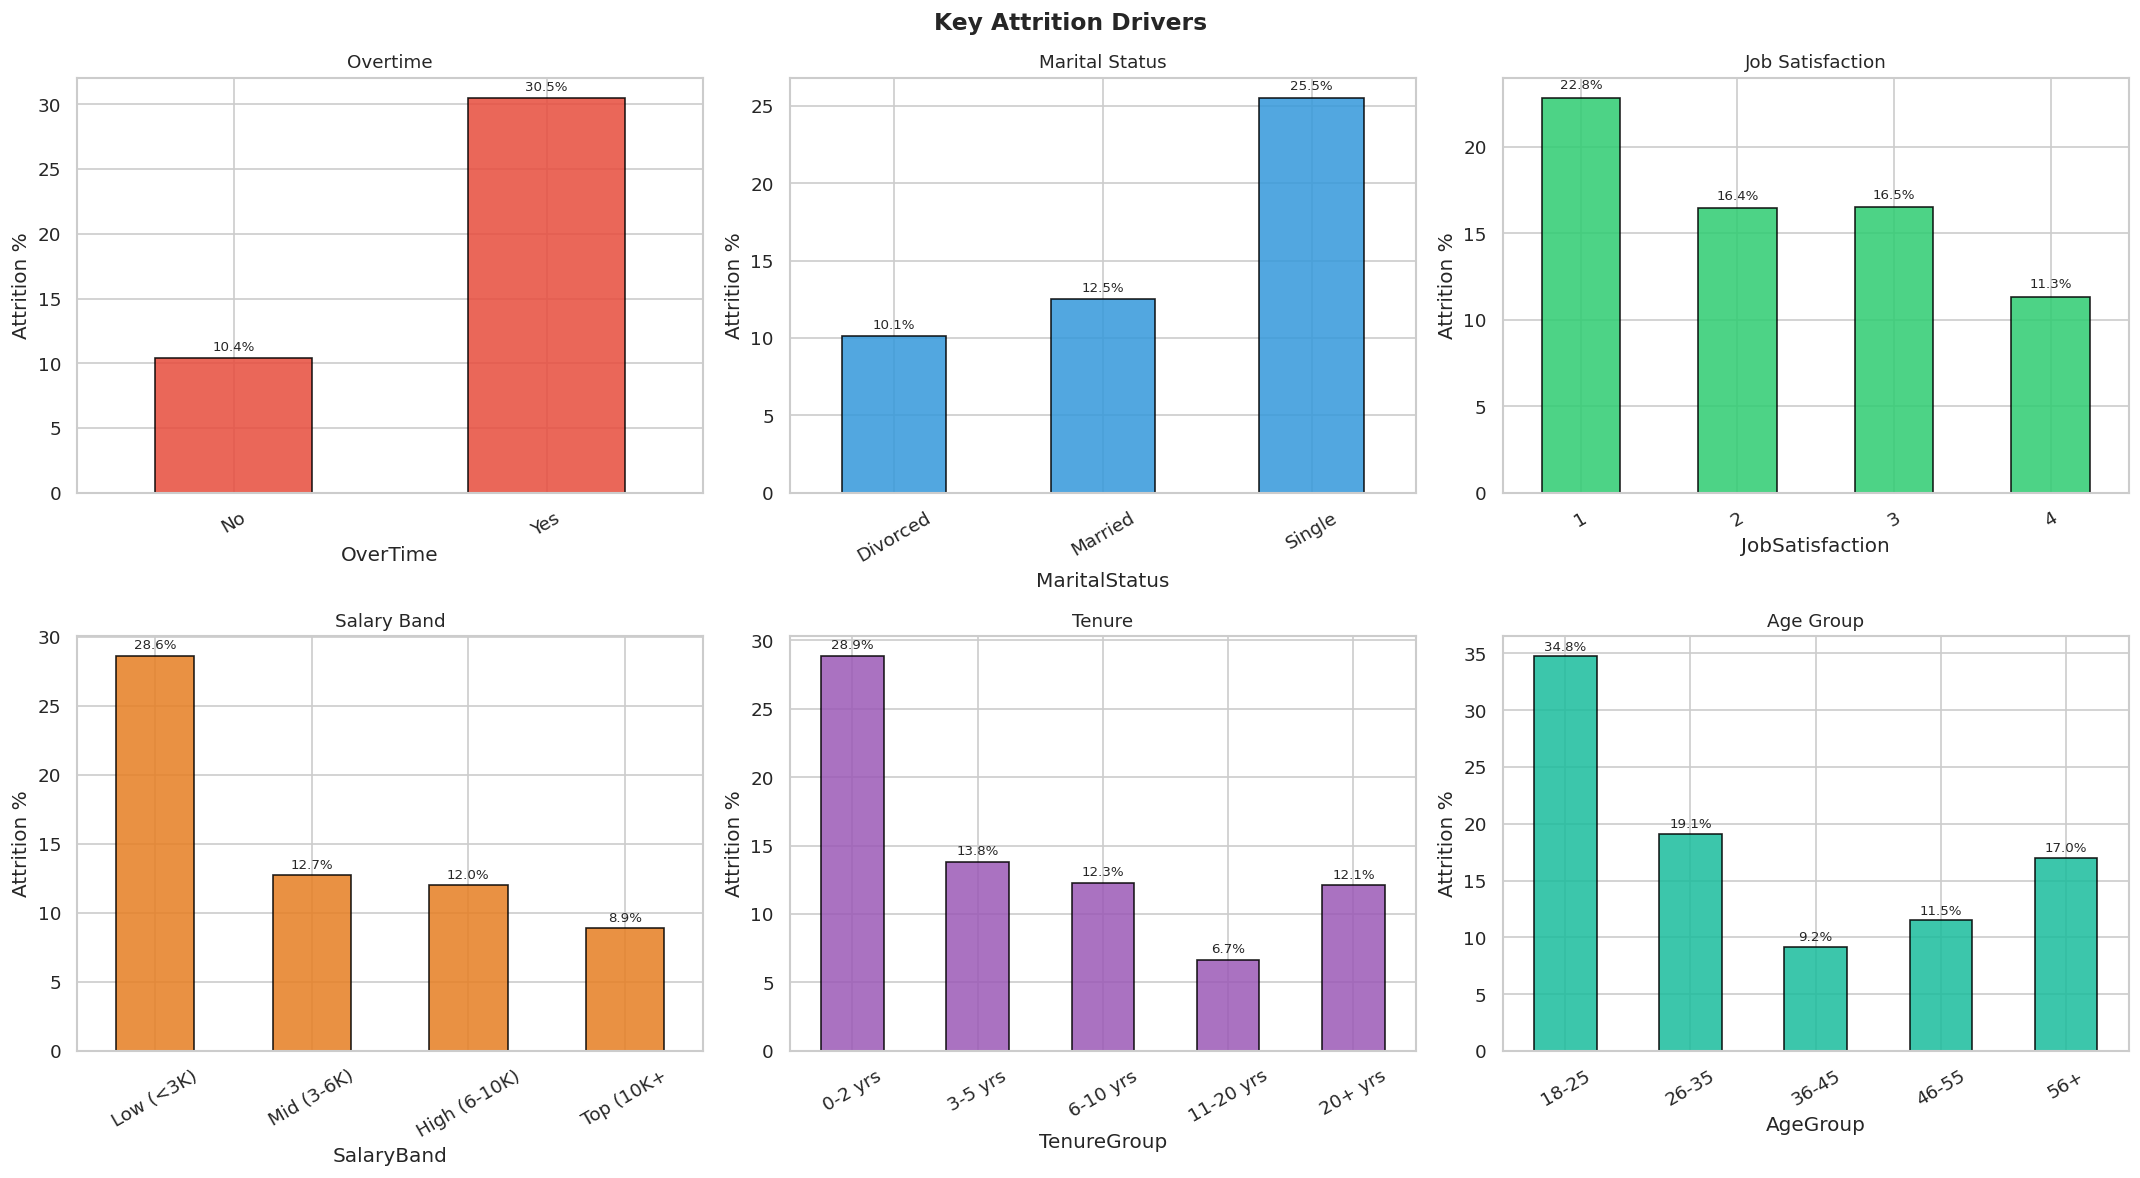

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Attrition Drivers', fontsize=14, fontweight='bold')

plot_vars = [
    ('OverTime', 'Overtime'),
    ('MaritalStatus', 'Marital Status'),
    ('JobSatisfaction', 'Job Satisfaction'),
    ('SalaryBand', 'Salary Band'),
    ('TenureGroup', 'Tenure'),
    ('AgeGroup', 'Age Group'),
]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#1abc9c']

for ax, (col, title), color in zip(axes.flatten(), plot_vars, colors):
    data = df.groupby(col)['Attrition_Binary'].mean() * 100
    data.plot(kind='bar', ax=ax, color=color, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Attrition %')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(ax.patches, data):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5, f'{val:.1f}%',
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('chart2_drivers.png', bbox_inches='tight')
plt.show()

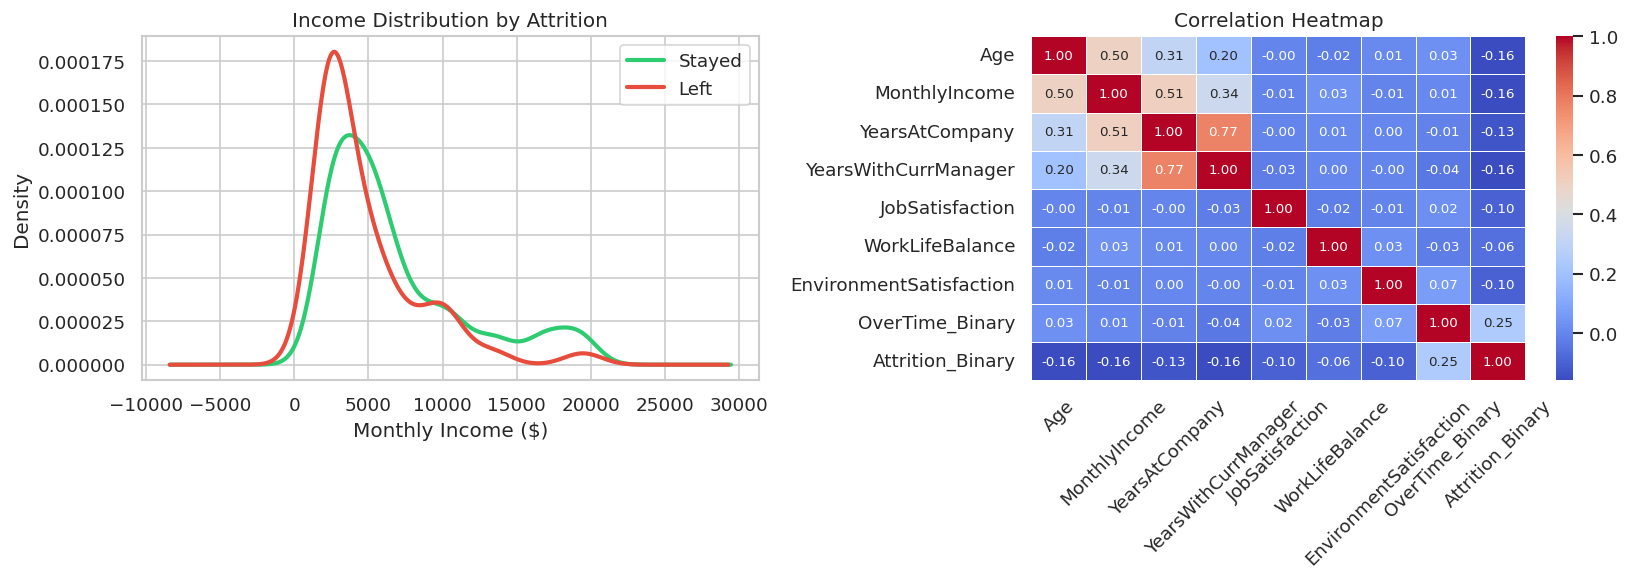

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Attrition']=='No']['MonthlyIncome'].plot(
    kind='kde', ax=axes[0], color='#2ecc71', label='Stayed', linewidth=2.5)
df[df['Attrition']=='Yes']['MonthlyIncome'].plot(
    kind='kde', ax=axes[0], color='#e74c3c', label='Left', linewidth=2.5)
axes[0].set_title('Income Distribution by Attrition')
axes[0].set_xlabel('Monthly Income ($)')
axes[0].legend()

num_cols = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'YearsWithCurrManager',
            'JobSatisfaction', 'WorkLifeBalance', 'EnvironmentSatisfaction',
            'OverTime_Binary', 'Attrition_Binary']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[1], linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title('Correlation Heatmap')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('chart3_salary_corr.png', bbox_inches='tight')
plt.show()

## 4. SQL Analysis (SQLite)

In [13]:
conn = sqlite3.connect('hr_analytics.db')
df.to_sql('employees', conn, if_exists='replace', index=False)

def sql(query):
    return pd.read_sql_query(query, conn)

sql('SELECT COUNT(*) as total FROM employees')

,total
0,1470


In [14]:
sql("""
SELECT
    COUNT(*) AS total_employees,
    SUM(Attrition_Binary) AS left_count,
    ROUND(AVG(Attrition_Binary) * 100, 2) AS attrition_rate_pct,
    ROUND(AVG(MonthlyIncome), 0) AS avg_income,
    ROUND(AVG(Age), 1) AS avg_age
FROM employees
""")

,total_employees,left_count,attrition_rate_pct,avg_income,avg_age
0,1470,237,16.12,6503.0,36.9


In [15]:
sql("""
SELECT
    Department,
    COUNT(*) AS headcount,
    SUM(Attrition_Binary) AS left_count,
    ROUND(AVG(Attrition_Binary) * 100, 1) AS attrition_pct,
    ROUND(AVG(MonthlyIncome), 0) AS avg_salary,
    ROUND(AVG(JobSatisfaction), 2) AS avg_satisfaction
FROM employees
GROUP BY Department
ORDER BY attrition_pct DESC
""")

,Department,headcount,left_count,attrition_pct,avg_salary,avg_satisfaction
0,Sales,446,92,20.6,6959.0,2.75
1,Human Resources,63,12,19.0,6655.0,2.60
2,Research & Development,961,133,13.8,6281.0,2.73


In [16]:
sql("""
SELECT
    JobRole, Department,
    COUNT(*) AS headcount,
    SUM(Attrition_Binary) AS left_count,
    ROUND(AVG(Attrition_Binary) * 100, 1) AS attrition_pct,
    ROUND(AVG(MonthlyIncome), 0) AS avg_income
FROM employees
GROUP BY JobRole, Department
ORDER BY attrition_pct DESC
LIMIT 5
""")

,JobRole,Department,headcount,left_count,attrition_pct,avg_income
0,Sales Representative,Sales,83,33,39.8,2626.0
1,Laboratory Technician,Research & Development,259,62,23.9,3237.0
2,Human Resources,Human Resources,52,12,23.1,4236.0
3,Sales Executive,Sales,326,57,17.5,6924.0
4,Research Scientist,Research & Development,292,47,16.1,3240.0


In [17]:
sql("""
SELECT
    OverTime,
    COUNT(*) AS employee_count,
    SUM(Attrition_Binary) AS left_count,
    ROUND(AVG(Attrition_Binary) * 100, 1) AS attrition_pct,
    ROUND(AVG(WorkLifeBalance), 2) AS avg_wlb
FROM employees
GROUP BY OverTime
ORDER BY attrition_pct DESC
""")

,OverTime,employee_count,left_count,attrition_pct,avg_wlb
0,Yes,416,127,30.5,2.73
1,No,1054,110,10.4,2.77


In [18]:
sql("""
WITH dept_stats AS (
    SELECT
        Department, JobRole,
        COUNT(*) AS headcount,
        SUM(Attrition_Binary) AS left_count,
        ROUND(AVG(Attrition_Binary) * 100, 1) AS attrition_pct
    FROM employees
    GROUP BY Department, JobRole
)
SELECT
    Department, JobRole, headcount, left_count, attrition_pct,
    RANK() OVER (ORDER BY attrition_pct DESC) AS overall_rank,
    RANK() OVER (PARTITION BY Department ORDER BY attrition_pct DESC) AS rank_in_dept
FROM dept_stats
ORDER BY overall_rank
LIMIT 10
""")

,Department,JobRole,headcount,left_count,attrition_pct,overall_rank,rank_in_dept
0,Sales,Sales Representative,83,33,39.8,1,1
1,Research & Development,Laboratory Technician,259,62,23.9,2,1
2,Human Resources,Human Resources,52,12,23.1,3,1
3,Sales,Sales Executive,326,57,17.5,4,2
4,Research & Development,Research Scientist,292,47,16.1,5,2
5,Research & Development,Healthcare Representative,131,9,6.9,6,3
6,Research & Development,Manufacturing Director,145,10,6.9,6,3
7,Research & Development,Manager,54,3,5.6,8,5
8,Sales,Manager,37,2,5.4,9,3
9,Research & Development,Research Director,80,2,2.5,10,6


In [19]:
sql("""
WITH promo AS (
    SELECT
        CASE
            WHEN YearsSinceLastPromotion = 0  THEN 'Just Promoted'
            WHEN YearsSinceLastPromotion <= 2 THEN '1-2 Years'
            WHEN YearsSinceLastPromotion <= 5 THEN '3-5 Years'
            ELSE '5+ Years'
        END AS promo_group,
        Attrition_Binary, MonthlyIncome, JobSatisfaction
    FROM employees
)
SELECT
    promo_group,
    COUNT(*) AS employee_count,
    SUM(Attrition_Binary) AS left_count,
    ROUND(AVG(Attrition_Binary) * 100, 1) AS attrition_pct,
    ROUND(AVG(MonthlyIncome), 0) AS avg_income
FROM promo
GROUP BY promo_group
ORDER BY attrition_pct DESC
""")

,promo_group,employee_count,left_count,attrition_pct,avg_income
0,Just Promoted,581,110,18.9,5500.0
1,5+ Years,215,35,16.3,9433.0
2,1-2 Years,516,76,14.7,5946.0
3,3-5 Years,158,16,10.1,8026.0


In [20]:
sql("""
WITH cost AS (
    SELECT
        Department, JobRole,
        SUM(CASE WHEN Attrition = 'Yes' THEN IncomePerYear ELSE 0 END) AS salary_lost,
        SUM(Attrition_Binary) AS left_count
    FROM employees
    GROUP BY Department, JobRole
)
SELECT
    Department, JobRole, left_count,
    ROUND(salary_lost, 0) AS annual_salary_lost,
    ROUND(salary_lost * 0.5, 0) AS replacement_cost_usd
FROM cost
WHERE left_count > 0
ORDER BY replacement_cost_usd DESC
LIMIT 8
""")

,Department,JobRole,left_count,annual_salary_lost,replacement_cost_usd
0,Sales,Sales Executive,57,5122476.0,2561238.0
1,Research & Development,Laboratory Technician,62,2171928.0,1085964.0
2,Research & Development,Research Scientist,47,1568184.0,784092.0
3,Sales,Sales Representative,33,936432.0,468216.0
4,Research & Development,Healthcare Representative,9,923208.0,461604.0
5,Research & Development,Manufacturing Director,10,883860.0,441930.0
6,Research & Development,Manager,3,543816.0,271908.0
7,Human Resources,Human Resources,12,535068.0,267534.0


## 5. Machine Learning

In [21]:
drop_cols = ['Attrition', 'Attrition_Binary', 'EmployeeNumber', 'EmployeeCount',
             'TenureGroup', 'AgeGroup', 'SalaryBand', 'IncomePerYear', 'OverTime_Binary']

feature_cols = [c for c in df.columns if c not in drop_cols]
df_ml = df[feature_cols + ['Attrition_Binary']].copy()

le = LabelEncoder()
for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

X = df_ml[feature_cols]
y = df_ml['Attrition_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Features: {X.shape[1]}')

Train: 1176 | Test: 294 | Features: 30


In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test

    cv_auc = cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc').mean()
    model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    results[name] = {
        'model': model,
        'cv_auc': cv_auc,
        'test_auc': roc_auc_score(y_test, y_prob),
        'test_acc': accuracy_score(y_test, y_pred),
        'y_pred': y_pred,
        'y_prob': y_prob
    }
    print(f'{name}: CV AUC={cv_auc:.4f} | Test AUC={roc_auc_score(y_test, y_prob):.4f} | Acc={accuracy_score(y_test, y_pred)*100:.1f}%')

Logistic Regression: CV AUC=0.8011 | Test AUC=0.8074 | Acc=75.2%
Random Forest: CV AUC=0.7939 | Test AUC=0.7862 | Acc=83.3%
Gradient Boosting: CV AUC=0.8194 | Test AUC=0.7984 | Acc=84.0%


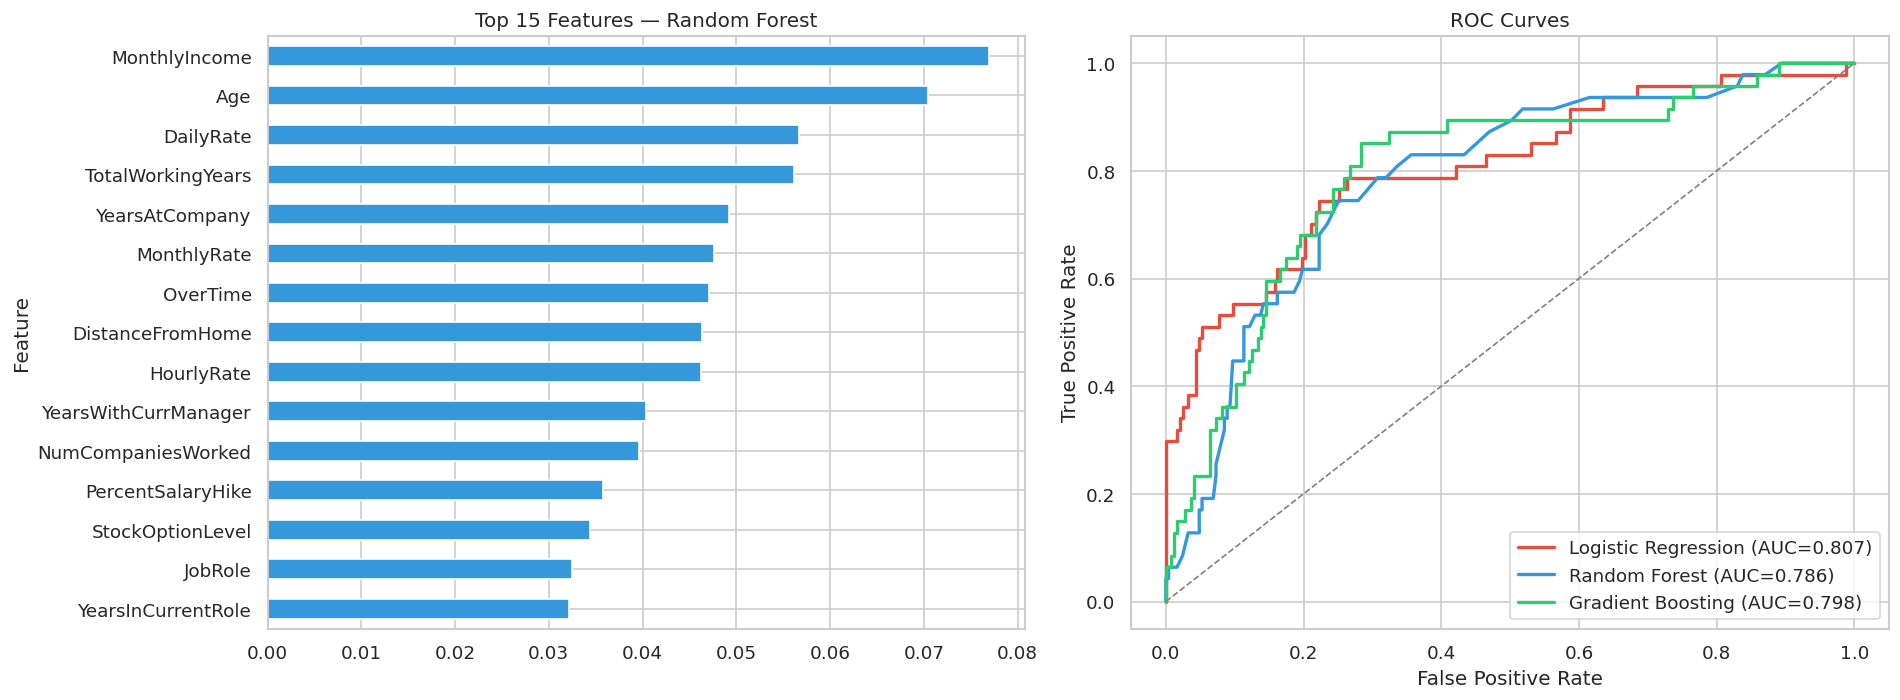

In [23]:
rf = results['Random Forest']['model']

imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})\
        .sort_values('Importance', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp.sort_values('Importance').plot(
    kind='barh', x='Feature', y='Importance',
    ax=axes[0], color='#3498db', legend=False
)
axes[0].set_title('Top 15 Features — Random Forest')

colors = ['#e74c3c', '#3498db', '#2ecc71']
for (name, res), col in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr, tpr, linewidth=2, color=col,
                 label=f"{name} (AUC={res['test_auc']:.3f})")
axes[1].plot([0,1],[0,1], 'gray', linestyle='--', linewidth=1)
axes[1].set_title('ROC Curves')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('chart4_model_results.png', bbox_inches='tight')
plt.show()

In [24]:
rf.fit(X_train, y_train)
all_probs = rf.predict_proba(X)[:, 1]

df_risk = df[['JobRole', 'Department', 'MonthlyIncome',
              'YearsAtCompany', 'OverTime', 'Attrition']].copy()
df_risk['Attrition_Risk_Score'] = (all_probs * 100).round(1)
df_risk['Risk_Level'] = pd.cut(
    df_risk['Attrition_Risk_Score'],
    bins=[0, 30, 60, 100],
    labels=['Low', 'Medium', 'High']
)

print(df_risk['Risk_Level'].value_counts())
df_risk[df_risk['Risk_Level']=='High'].sort_values('Attrition_Risk_Score', ascending=False).head(10)

Risk_Level
Low       1231
High       195
Medium      32
Name: count, dtype: int64


,JobRole,Department,MonthlyIncome,YearsAtCompany,OverTime,Attrition,Attrition_Risk_Score,Risk_Level
463,Laboratory Technician,Research & Development,2340,1,Yes,Yes,94.0,High
127,Sales Representative,Sales,1675,0,Yes,Yes,91.0,High
102,Laboratory Technician,Research & Development,2926,1,Yes,Yes,90.5,High
1012,Sales Representative,Sales,1359,1,No,Yes,90.5,High
1136,Laboratory Technician,Research & Development,2408,1,Yes,Yes,90.5,High
683,Sales Representative,Sales,2413,1,Yes,Yes,90.5,High
1332,Research Scientist,Research & Development,2439,1,Yes,Yes,90.5,High
688,Sales Representative,Sales,2121,1,Yes,Yes,90.5,High
1153,Sales Representative,Sales,1569,0,Yes,Yes,90.0,High
731,Research Scientist,Research & Development,2600,1,Yes,Yes,90.0,High


In [25]:
df_risk.to_csv('hr_attrition_risk_scores.csv', index=False)
print('Saved hr_attrition_risk_scores.csv')

Saved hr_attrition_risk_scores.csv


## 6. Download outputs

In [26]:
from google.colab import files
import os

for f in ['hr_attrition_cleaned.csv', 'hr_attrition_risk_scores.csv',
          'chart1_overview.png', 'chart2_drivers.png',
          'chart3_salary_corr.png', 'chart4_model_results.png']:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>